<a href="https://colab.research.google.com/github/cs24dse007-boop/CSL701-CS04-Machine-Learning-Lab/blob/main/Experiments/ML_exp_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Omkar M. Bhalekar

Batch :cs1


Roll Number :cs04



### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import normalized_mutual_info_score

In [ ]:
df = pd.read_csv("/content/brca.csv")

print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  x.area_mean  \
0           1         13.540           14.36             87.46        566.3   
1           2         13.080           15.71             85.63        520.0   
2           3          9.504           12.44             60.34        273.9   
3           4         13.030           18.42             82.61        523.8   
4           5          8.196           16.84             51.71        201.9   

   x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
0            0.09779             0.08129           0.06664   
1            0.10750             0.12700           0.04568   
2            0.10240             0.06492           0.02956   
3            0.08983             0.03766           0.02562   
4            0.08600             0.05943           0.01588   

   x.concave_pts_mean  x.symmetry_mean  ...  x.texture_worst  \
0            0.047810           0.1885  ...            19.2

# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (569, 32)


In [ ]:
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean',
       'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean',
       'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean',
       'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se',
       'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se',
       'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se',
       'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst',
       'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst',
       'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst',
       'x.fractal_dim_worst', 'y'],
      dtype='object')


In [ ]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Unnamed: 0               int64
x.radius_mean          float64
x.texture_mean         float64
x.perimeter_mean       float64
x.area_mean            float64
x.smoothness_mean      float64
x.compactness_mean     float64
x.concavity_mean       float64
x.concave_pts_mean     float64
x.symmetry_mean        float64
x.fractal_dim_mean     float64
x.radius_se            float64
x.texture_se           float64
x.perimeter_se         float64
x.area_se              float64
x.smoothness_se        float64
x.compactness_se       float64
x.concavity_se         float64
x.concave_pts_se       float64
x.symmetry_se          float64
x.fractal_dim_se       float64
x.radius_worst         float64
x.texture_worst        float64
x.perimeter_worst      float64
x.area_worst           float64
x.smoothness_worst     float64
x.compactness_worst    float64
x.concavity_worst      float64
x.concave_pts_worst    float64
x.symmetry_worst       float64
x.fractal_dim_worst    float64
y                       ob

In [ ]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Unnamed: 0             0
x.radius_mean          0
x.texture_mean         0
x.perimeter_mean       0
x.area_mean            0
x.smoothness_mean      0
x.compactness_mean     0
x.concavity_mean       0
x.concave_pts_mean     0
x.symmetry_mean        0
x.fractal_dim_mean     0
x.radius_se            0
x.texture_se           0
x.perimeter_se         0
x.area_se              0
x.smoothness_se        0
x.compactness_se       0
x.concavity_se         0
x.concave_pts_se       0
x.symmetry_se          0
x.fractal_dim_se       0
x.radius_worst         0
x.texture_worst        0
x.perimeter_worst      0
x.area_worst           0
x.smoothness_worst     0
x.compactness_worst    0
x.concavity_worst      0
x.concave_pts_worst    0
x.symmetry_worst       0
x.fractal_dim_worst    0
y                      0
dtype: int64


In [ ]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
       Unnamed: 0  x.radius_mean  x.texture_mean  x.perimeter_mean  \
count  569.000000     569.000000      569.000000        569.000000   
mean   285.000000      14.127292       19.289649         91.969033   
std    164.400426       3.524049        4.301036         24.298981   
min      1.000000       6.981000        9.710000         43.790000   
25%    143.000000      11.700000       16.170000         75.170000   
50%    285.000000      13.370000       18.840000         86.240000   
75%    427.000000      15.780000       21.800000        104.100000   
max    569.000000      28.110000       39.280000        188.500000   

       x.area_mean  x.smoothness_mean  x.compactness_mean  x.concavity_mean  \
count   569.000000         569.000000          569.000000        569.000000   
mean    654.889104           0.096360            0.104341          0.088799   
std     351.914129           0.014064            0.052813          0.079720   
min     143.500000           0.0

In [ ]:
print("\nDiagnosis Distribution:")
print(df["y"].value_counts())


Diagnosis Distribution:
y
B    357
M    212
Name: count, dtype: int64


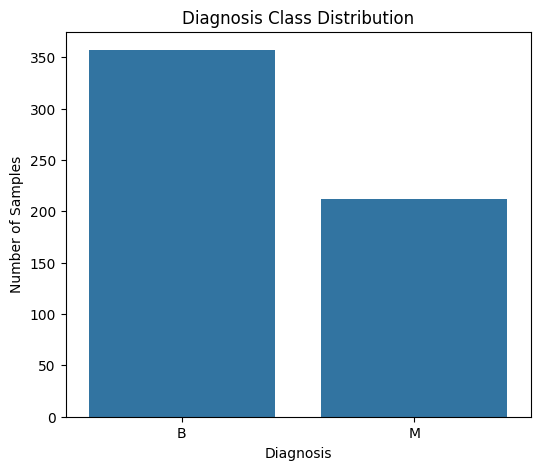

In [ ]:
plt.figure(figsize=(6, 5))

sns.countplot(x="y", data=df)

plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")

plt.show()

# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
# Remove identifier column
df_clean = df.drop("Unnamed: 0", axis=1)

# Convert target values
# B = 0 (Benign)
# M = 1 (Malignant)

df_clean["y"] = df_clean["y"].map({
    "B": 0,
    "M": 1
})

# Separate features and target
X = df_clean.drop("y", axis=1)
y = df_clean["y"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (569, 30)
Target Shape: (569,)


In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Feature Shape:", X_scaled.shape)

print("\nFirst 5 scaled samples:")
print(X_scaled[:5])

Scaled Feature Shape: (569, 30)

First 5 scaled samples:
[[-1.66799191e-01 -1.14716230e+00 -1.85727988e-01 -2.51956501e-01
   1.01746571e-01 -4.36850252e-01 -2.78209570e-01 -2.86092890e-02
   2.67911231e-01 -7.28309656e-01 -4.88225261e-01 -7.76998992e-01
  -4.00014052e-01 -3.69124423e-01  4.73692902e-01 -6.07974170e-01
  -2.66042547e-01  2.19609651e-01 -8.98764242e-02 -5.65449394e-01
  -2.40047958e-01 -1.04500496e+00 -2.25217058e-01 -2.97760754e-01
   5.09873049e-01 -4.89605212e-01 -1.59222529e-01  2.16122925e-01
   1.23346531e-01 -6.29291894e-01]
 [-2.97445722e-01 -8.33008236e-01 -2.61106055e-01 -3.83638452e-01
   7.92763012e-01  4.29421872e-01 -5.41361764e-01 -4.59626734e-01
   5.67288590e-01  7.53086584e-01 -7.93925350e-01 -8.51205657e-01
  -7.34159715e-01 -5.64719621e-01 -9.81366092e-01 -3.63177987e-01
  -4.94494435e-01 -8.60706722e-01 -4.55533505e-01 -5.18167976e-01
  -3.66368301e-01 -8.44707093e-01 -3.32743935e-01 -4.39624310e-01
  -5.12263607e-02  1.48442923e-01 -3.99098706e-01 

# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
# Calculate pairwise Euclidean distances
distance_vector = pdist(
    X_scaled,
    metric="euclidean"
)

# Convert into square matrix
distance_matrix = squareform(distance_vector)

print("Distance Matrix Shape:",
      distance_matrix.shape)

print("\nFirst 5 x 5 Distance Matrix:")
print(distance_matrix[:5, :5])

Distance Matrix Shape: (569, 569)

First 5 x 5 Distance Matrix:
[[0.         3.10724668 3.62314178 5.20448164 4.46708561]
 [3.10724668 0.         4.01027585 5.62302017 4.37098277]
 [3.62314178 4.01027585 0.         5.12193591 2.94839575]
 [5.20448164 5.62302017 5.12193591 0.         5.02798792]
 [4.46708561 4.37098277 2.94839575 5.02798792 0.        ]]


In [ ]:
G = nx.Graph()

# Add nodes
G.add_nodes_from(range(len(X_scaled)))

# Add weighted edges
for i in range(len(X_scaled)):
    for j in range(i + 1, len(X_scaled)):
        G.add_edge(
            i,
            j,
            weight=distance_matrix[i, j]
        )

print("\nNumber of Nodes:",
      G.number_of_nodes())

print("Number of Edges:",
      G.number_of_edges())


Number of Nodes: 569
Number of Edges: 161596


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
# Compute MST
mst_sparse = minimum_spanning_tree(
    distance_matrix
)

# Convert to NetworkX graph
mst = nx.from_scipy_sparse_array(
    mst_sparse
)

print("MST Nodes:",
      mst.number_of_nodes())

print("MST Edges:",
      mst.number_of_edges())

MST Nodes: 569
MST Edges: 568


In [ ]:
mst_edges = []

for u, v, data in mst.edges(data=True):

    mst_edges.append(
        (u, v, data["weight"])
    )

mst_edges_df = pd.DataFrame(
    mst_edges,
    columns=[
        "Node1",
        "Node2",
        "Weight"
    ]
)

print(mst_edges_df.head())

print("\nTotal MST Edges:",
      len(mst_edges_df))

   Node1  Node2    Weight
0      0     81  1.688590
1      0    108  2.171448
2      1    105  1.660727
3      2     70  2.218949
4      3    170  2.346213

Total MST Edges: 568


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
mst_edges_sorted = sorted(
    mst_edges,
    key=lambda x: x[2],
    reverse=True
)

print("10 Largest MST Edges:")

for edge in mst_edges_sorted[:10]:
    print(edge)

10 Largest MST Edges:
(544, 553, 12.299945385815649)
(18, 69, 10.476074912430871)
(48, 468, 8.826434347268258)
(467, 544, 8.26854194336771)
(424, 429, 8.07798415946937)
(360, 454, 7.87103948027092)
(18, 208, 7.791092719319788)
(412, 515, 7.089525607141025)
(454, 515, 7.062629598697372)
(369, 395, 6.968998137974113)


In [ ]:
# Copy MST
mst_cluster = mst.copy()

# Get largest edge
largest_edge = mst_edges_sorted[0]

node1 = int(largest_edge[0])
node2 = int(largest_edge[1])
weight = largest_edge[2]

print("\nLargest Edge:")
print("Node 1:", node1)
print("Node 2:", node2)
print("Weight:", weight)

# Remove largest edge
mst_cluster.remove_edge(
    node1,
    node2
)


Largest Edge:
Node 1: 544
Node 2: 553
Weight: 12.299945385815649


In [ ]:
components = list(
    nx.connected_components(
        mst_cluster
    )
)

print("\nNumber of Clusters:",
      len(components))

print("\nCluster Sizes:")

for i, component in enumerate(components):

    print(
        "Cluster",
        i,
        ":",
        len(component),
        "samples"
    )


Number of Clusters: 2

Cluster Sizes:
Cluster 0 : 567 samples
Cluster 1 : 2 samples


In [ ]:
cluster_labels = np.zeros(
    len(X_scaled),
    dtype=int
)

for cluster_id, component in enumerate(
    components
):

    for node in component:
        cluster_labels[node] = cluster_id

print("\nCluster Labels:")
print(cluster_labels)

print("\nCluster Distribution:")
print(
    pd.Series(
        cluster_labels
    ).value_counts()
)


Cluster Labels:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0

# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
silhouette = silhouette_score(
    X_scaled,
    cluster_labels
)

print("Silhouette Score:",
      silhouette)

Silhouette Score: 0.6606668813897673


In [ ]:
ari = adjusted_rand_score(
    y,
    cluster_labels
)

print("Adjusted Rand Index:",
      ari)

Adjusted Rand Index: 0.0048283446965917305


In [ ]:
nmi = normalized_mutual_info_score(
    y,
    cluster_labels
)

print("Normalized Mutual Information:",
      nmi)

Normalized Mutual Information: 0.010182219220269649


In [ ]:
print("======================================")
print("       MST CLUSTERING RESULTS")
print("======================================")

print(
    "Silhouette Score :",
    round(silhouette, 4)
)

print(
    "Adjusted Rand Index (ARI) :",
    round(ari, 4)
)

print(
    "Normalized Mutual Information (NMI) :",
    round(nmi, 4)
)

       MST CLUSTERING RESULTS
Silhouette Score : 0.6607
Adjusted Rand Index (ARI) : 0.0048
Normalized Mutual Information (NMI) : 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

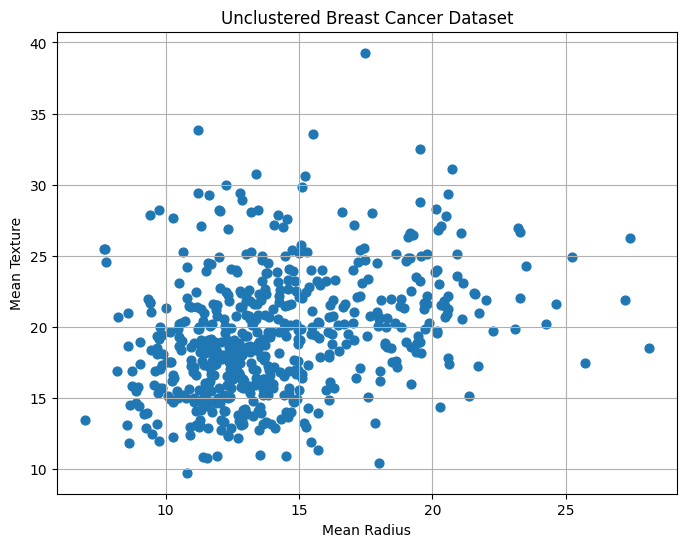

In [ ]:
feature_x = "x.radius_mean"
feature_y = "x.texture_mean"

plt.figure(figsize=(8, 6))

plt.scatter(
    df[feature_x],
    df[feature_y],
    s=40
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Unclustered Breast Cancer Dataset")

plt.grid()

plt.show()

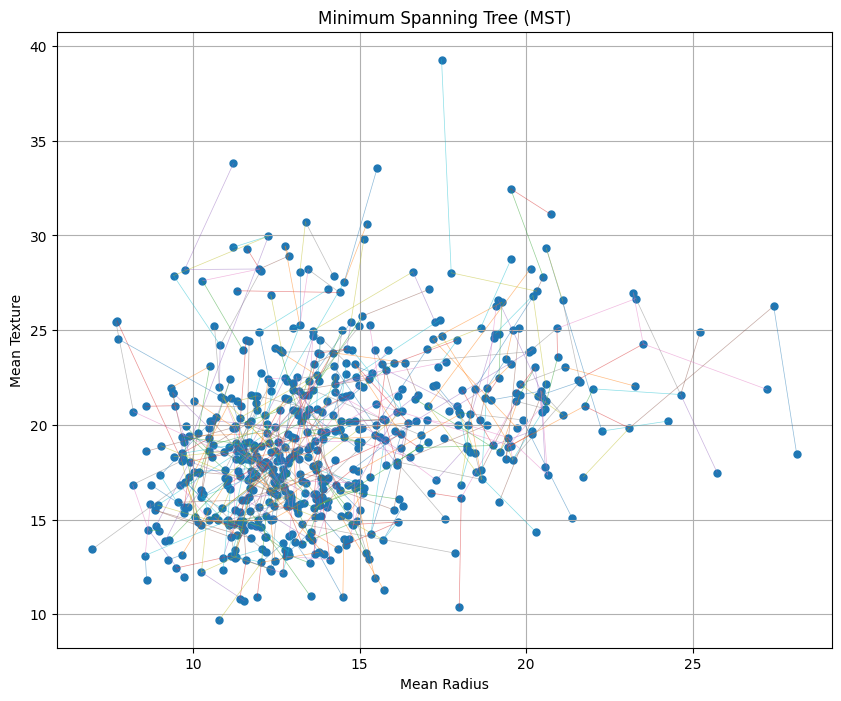

In [ ]:
plt.figure(figsize=(10, 8))

# Draw MST edges
for u, v, data in mst.edges(data=True):

    plt.plot(
        [
            df.iloc[u][feature_x],
            df.iloc[v][feature_x]
        ],

        [
            df.iloc[u][feature_y],
            df.iloc[v][feature_y]
        ],

        linewidth=0.5,
        alpha=0.5
    )

# Draw data points
plt.scatter(
    df[feature_x],
    df[feature_y],
    s=25
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Minimum Spanning Tree (MST)")

plt.grid()

plt.show()

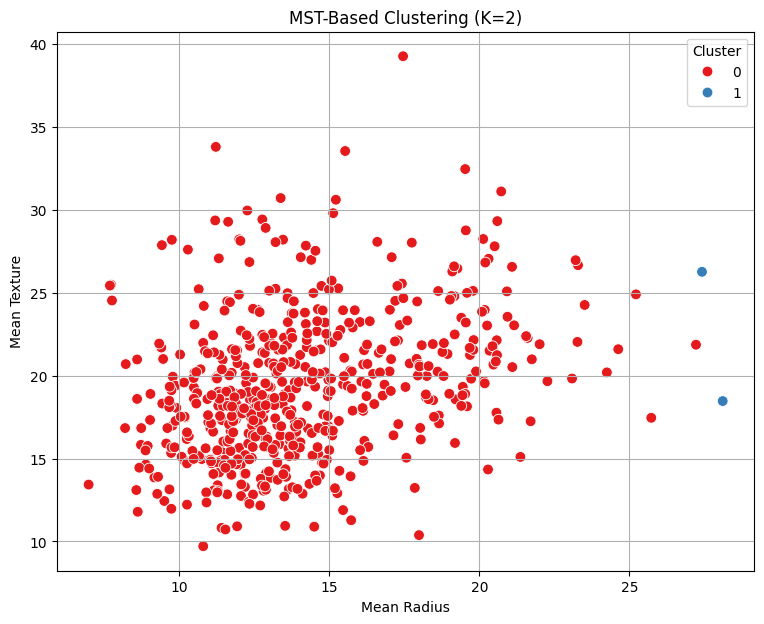

In [ ]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    x=df[feature_x],
    y=df[feature_y],
    hue=cluster_labels,
    palette="Set1",
    s=60
)

plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")

plt.title(
    "MST-Based Clustering (K=2)"
)

plt.legend(title="Cluster")

plt.grid()

plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.